In [1]:
import pandas as pd

# Define file paths
input_file = r"C:\Users\kdivy\OneDrive\Desktop\COMP SYS BIOLOGY\gwas-association-downloaded_2025-02-18-MONDO_0004975-withChildTraits (1).xlsx"
output_file = r"C:\Users\kdivy\OneDrive\Desktop\COMP SYS BIOLOGY\significant_snps.xlsx"

# Load the GWAS Catalog file
df = pd.read_excel(input_file, sheet_name=0)  # Reads the first sheet

# Standardize column names
df.columns = df.columns.str.strip().str.upper()

# Filter for significant SNPs (P-VALUE < 5E-8)
significant_snps = df[df['P-VALUE'] < 5E-8][['SNPS', 'MAPPED_GENE', 'P-VALUE', 'UPSTREAM_GENE_DISTANCE', 'DOWNSTREAM_GENE_DISTANCE']]

# Rename columns
significant_snps.rename(columns={'P-VALUE': 'PVALUE', 'SNPS': 'SNP'}, inplace=True)

# Save the filtered data to an Excel file
significant_snps.to_excel(output_file, index=False)

print(f"Significant SNPs file saved at: {output_file}")


Significant SNPs file saved at: C:\Users\kdivy\OneDrive\Desktop\COMP SYS BIOLOGY\significant_snps.xlsx


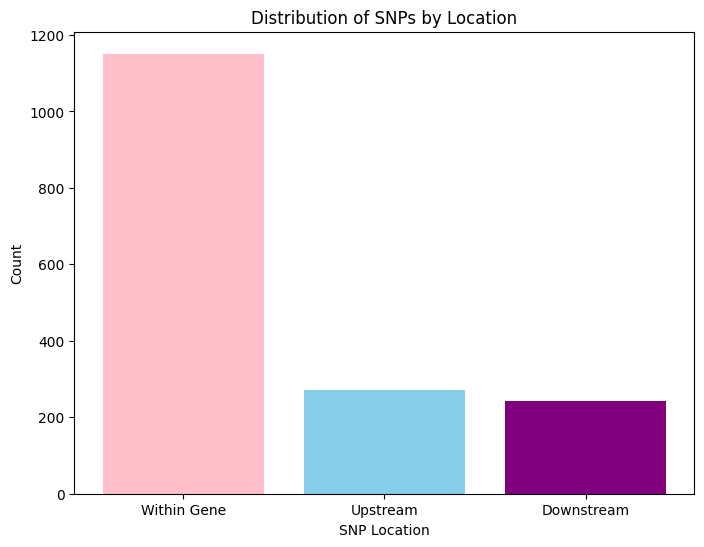

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Define file path
file_path = r"C:\Users\kdivy\OneDrive\Desktop\COMP SYS BIOLOGY\significant_snps.xlsx"

# Load the dataset
df = pd.read_excel(file_path)

# Function to determine SNP location
def classify_snp(row):
    upstream_dist = row['UPSTREAM_GENE_DISTANCE']
    downstream_dist = row['DOWNSTREAM_GENE_DISTANCE']

    if pd.isna(upstream_dist) and pd.isna(downstream_dist):
        return 'Within Gene'
    elif pd.isna(upstream_dist):
        return 'Upstream'
    elif pd.isna(downstream_dist):
        return 'Downstream'
    else:
        return 'Upstream' if upstream_dist < downstream_dist else 'Downstream'

# Apply classification function
df['SNP_Location'] = df.apply(classify_snp, axis=1)

# Count the occurrences of each SNP location
snp_counts = df['SNP_Location'].value_counts()

# Define unique colors for each category
colors = {'Within Gene': 'pink', 'Upstream': 'skyblue', 'Downstream': 'purple'}

# Plot the bar chart with different colors
plt.figure(figsize=(8, 6))
plt.bar(snp_counts.index, snp_counts.values, color=[colors[loc] for loc in snp_counts.index])
plt.xlabel('SNP Location')
plt.ylabel('Count')
plt.title('Distribution of SNPs by Location')
plt.show()


In [3]:
import pandas as pd

# Define file paths
input_filepath = r"C:\Users\kdivy\OneDrive\Desktop\COMP SYS BIOLOGY\gwas-association-downloaded_2025-02-18-MONDO_0004975-withChildTraits (1).xlsx"
output_filepath = r"C:\Users\kdivy\OneDrive\Desktop\COMP SYS BIOLOGY\filtered_significant_snps.xlsx"

# Load GWAS dataset from the first sheet
df = pd.read_excel(input_filepath, sheet_name=0)

# Standardize column names to maintain consistency
df.columns = df.columns.str.strip()  # Remove extra spaces
df.rename(columns={'P-VALUE': 'PValue', 'SNPS': 'SNP_ID', 'CHR_ID': 'Chromosome'}, inplace=True)

# Filter SNPs with P-Value < 5E-8, indicating strong statistical significance
significant_snps = df[df['PValue'] < 5E-8][['SNP_ID', 'Chromosome', 'MAPPED_GENE', 'PValue', 'UPSTREAM_GENE_DISTANCE', 'DOWNSTREAM_GENE_DISTANCE']]

# Export the filtered SNPs to a new Excel file
significant_snps.to_excel(output_filepath, index=False)

print(f"Filtered significant SNPs saved successfully at: {output_filepath}")

Filtered significant SNPs saved successfully at: C:\Users\kdivy\OneDrive\Desktop\COMP SYS BIOLOGY\filtered_significant_snps.xlsx


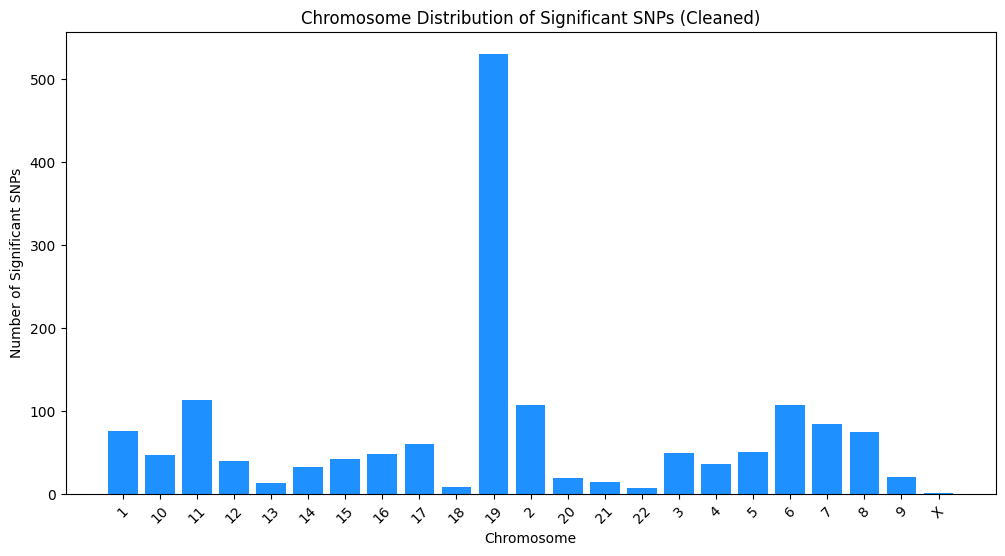

In [4]:
# Define file path for the updated significant SNPs file
file_path = r"C:\Users\kdivy\OneDrive\Desktop\COMP SYS BIOLOGY\filtered_significant_snps.xlsx"

# Load the dataset
df_snps_chr = pd.read_excel(file_path)

# Convert chromosome column to string and clean up invalid characters
df_snps_chr['Chromosome'] = df_snps_chr['Chromosome'].astype(str).str.strip()
df_snps_chr['Chromosome'] = df_snps_chr['Chromosome'].str.replace(r'[^0-9XYMT]', '', regex=True)

# Define valid chromosome values (1-22, X, Y, MT)
valid_chromosomes = [str(i) for i in range(1, 23)] + ['X', 'Y', 'MT']

# Filter only valid chromosome entries
df_cleaned = df_snps_chr[df_snps_chr['Chromosome'].isin(valid_chromosomes)]

# Count SNPs per chromosome
chromosome_counts_cleaned = df_cleaned['Chromosome'].value_counts().sort_index()

# Plot the cleaned chromosome distribution
plt.figure(figsize=(12, 6))
plt.bar(chromosome_counts_cleaned.index, chromosome_counts_cleaned.values, color='dodgerblue')
plt.xlabel('Chromosome')
plt.ylabel('Number of Significant SNPs')
plt.title('Chromosome Distribution of Significant SNPs (Cleaned)')
plt.xticks(rotation=45)  # Rotate labels for better readability
plt.show()

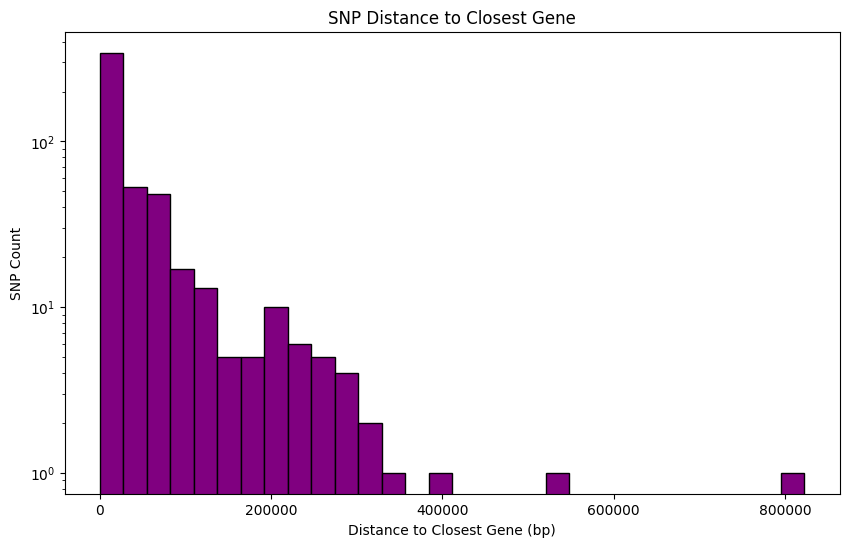

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
file_path = r"C:\Users\kdivy\OneDrive\Desktop\COMP SYS BIOLOGY\filtered_significant_snps.xlsx"
df = pd.read_excel(file_path)

# Compute the closest gene distance
df['Closest_Gene_Distance'] = df[['UPSTREAM_GENE_DISTANCE', 'DOWNSTREAM_GENE_DISTANCE']].min(axis=1)

# Drop missing values
df = df.dropna(subset=['Closest_Gene_Distance'])

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(df['Closest_Gene_Distance'], bins=30, color='purple', edgecolor='black')
plt.xlabel('Distance to Closest Gene (bp)')
plt.ylabel('SNP Count')
plt.title('SNP Distance to Closest Gene')
plt.yscale('log')  # Log scale for better visibility
plt.show()


In [6]:
import pandas as pd

# Define file paths
significant_snps_file = r"C:\Users\kdivy\OneDrive\Desktop\COMP SYS BIOLOGY\filtered_significant_snps.xlsx"
eqtl_file = r"C:\Users\kdivy\OneDrive\Desktop\COMP SYS BIOLOGY\EQTL.tsv"

# Load datasets
df_snps = pd.read_excel(significant_snps_file)
df_eqtl = pd.read_csv(eqtl_file, sep='\t')

# Clean column names by stripping extra spaces
df_eqtl.columns = df_eqtl.columns.str.strip()

# Filter the significant SNPs dataset to include only upstream SNPs
df_upstream_snps = df_snps[df_snps['UPSTREAM_GENE_DISTANCE'].notna()]

# Merge with eQTL dataset based on SNP ID (rsid)
df_eqtl_merged = df_upstream_snps.merge(df_eqtl, left_on='SNP_ID', right_on='rsid', how='inner')

# Filter for eQTLs with P-Value < 0.05 (using 'aveALL' as the general eQTL significance score)
df_eqtl_filtered = df_eqtl_merged[df_eqtl_merged['aveALL'] < 0.05]

# Select required columns: eQTL SNP, Associated Gene, P-Value, and Tissues
columns_to_keep = ['rsid', 'geneSymbol', 'aveALL', 'CRBL', 'FCTX', 'HIPP', 'MEDU', 'OCTX', 'PUTM', 'SNIG', 'TCTX', 'THAL', 'WHMT']
df_eqtl_final = df_eqtl_filtered[columns_to_keep]

# Rename columns for clarity
df_eqtl_final.rename(columns={'rsid': 'eQTL', 'geneSymbol': 'Associated_Gene', 'aveALL': 'P_Value'}, inplace=True)

# Save the filtered results to an Excel file
output_file = r"C:\Users\kdivy\OneDrive\Desktop\COMP SYS BIOLOGY\filtered_eQTLs.xlsx"
df_eqtl_final.to_excel(output_file, index=False)

print(f"Filtered eQTL results saved successfully at: {output_file}")

Filtered eQTL results saved successfully at: C:\Users\kdivy\OneDrive\Desktop\COMP SYS BIOLOGY\filtered_eQTLs.xlsx


C:\Users\kdivy\AppData\Local\Temp\ipykernel_30508\3156526599.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_eqtl_final.rename(columns={'rsid': 'eQTL', 'geneSymbol': 'Associated_Gene', 'aveALL': 'P_Value'}, inplace=True)
